# Creating boundary conditions of age in panan01
**Notes**:
- Taken from Adele who used this for the panan-01, panan-005 and panan-0025 models
- This notebook requires conda analysis environment hh5 anaysis3-22.10
- Some problems with the interpolation at continents if model land boundaries don't exactly match up with ACCESS-OM2.
- Source data used for ages is the monthly age output from the last year of *01deg_jra55v13_ryf9091*

In [1]:
import netCDF4
import xarray as xr
import xesmf as xe
from itertools import cycle
import os
import dask
import numpy as np
import intake
import pandas as pd
import dask.array as da
import dask.bag as db
from pykdtree.kdtree import KDTree
from dask.diagnostics import ProgressBar
import subprocess
import matplotlib.pyplot as plt
from glob import glob

import cmocean.cm as cmocean

xr.set_options(keep_attrs=True) ## This ensures that performing simple operations with xarray (eg converting temperature to Celsius) preserves attributes

from dask.distributed import Client
client = Client(threads_per_worker = 1)

In [2]:
catalog = intake.cat.access_nri

### Part 1 - Importing age from OM2-01 last year's run

In [3]:
time_tointerp = catalog['01deg_jra55v150_iaf_cycle1'].search(variable='sfc_salt_flux_ice',frequency="1day").to_dask(xarray_open_kwargs={'decode_timedelta':True}).time
time_tointerp = time_tointerp.sel(time=slice('1971-12-01','1973-01-01'))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/intake_esm/core.py:259: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [4]:
time_monthly = catalog['01deg_jra55v150_iaf_cycle1'].search(variable='sfc_salt_flux_ice',frequency="1mon").to_dask(xarray_open_kwargs={'decode_timedelta':True}).time
time_monthly = time_monthly.sel(time=slice('1971-12-01','1973-02-01'))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/intake_esm/core.py:259: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [5]:
OM2ryf_age = catalog["01deg_jra55v13_ryf9091"].search(variable="age_global", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True}).sel(yt_ocean=slice(-40,-30)).isel(time=slice(-25,-11))
OM2ryf_age['time']=time_monthly
OM2ryf_age.load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/intake_esm/core.py:259: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 122.78 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.Dataset> Size: 2GB
Dimensions:     (time: 14, st_ocean: 75, yt_ocean: 122, xt_ocean: 3600)
Coordinates:
  * xt_ocean    (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.85 79.95
  * yt_ocean    (yt_ocean) float64 976B -39.95 -39.88 -39.8 ... -30.15 -30.07
  * st_ocean    (st_ocean) float64 600B 0.5413 1.681 ... 5.511e+03 5.709e+03
  * time        (time) datetime64[ns] 112B 1971-12-16T12:00:00 ... 1973-01-16...
Data variables:
    age_global  (time, st_ocean, yt_ocean, xt_ocean) float32 2GB 0.0 0.0 ... nan
Attributes:
    filename:                        ocean.nc
    title:                           ACCESS-OM2-01
    grid_type:                       mosaic
    grid_tile:                       1
    intake_esm_vars:                 ['age_global']
    intake_esm_attrs:filename:       ocean.nc
    intake_esm_attrs:file_id:        ocean.1mon.grid_xt_ocean:3600.grid_xu_oc...
    intake_esm_attrs:frequency:      1mon
    intake_esm_attrs:realm:          ocean
    intake_esm_attrs:_data_format_:  netcdf
    intake_esm_dataset_key:          ocean.1mon.grid_xt_ocean:3600.grid_xu_oc...

In [6]:
#interpolating time into daily'
OM2ryf_age = OM2ryf_age.interp(time = time_tointerp).sel(time=slice('1972-01-01','1972-12-31')).compute()

In [7]:
OM2ryf_age_365 = OM2ryf_age.isel(time=slice(0,365))

In [8]:
# range of files to use
surface_tracer_vars = ["age_global"]
line_tracer_vars = ["eta_t"]
surface_velocity_vars = ["u", "v", "dzu"]

chunks = {
    "T": {"time": 1, "zl": 7, "yt_ocean": 300, "xt_ocean": None},
    "U": {"time": 1, "zl": 7, "yu_ocean": 300, "xu_ocean": None},
}

# open target grid dataset
# we interpolate onto the hgrid
dg = xr.open_dataset("/g/data/ik11/inputs/mom6/panan-01/ocean_hgrid.nc").isel(nyp=[-1])

# interpolation grid
dg_out = xr.Dataset(
    {"lat": (["location"], dg.y.squeeze().data), "lon": (["location"], dg.x.squeeze().data)}
)

In [9]:
# open source datasets
surface_vars =  surface_tracer_vars

in_datasets = {}
for var, staggering in list(zip(surface_tracer_vars, cycle("T"))) + list(
    zip(surface_velocity_vars, cycle("U"))
):
    if var=='pot_temp':
        var_name = 'temp'
    else:
        var_name = var
    d = OM2ryf_age_365
    in_datasets[var] = staggering, d

d_tracer = d


In [10]:
# reduce selection around target latitude
# and remove spatial chunks (required for xesmf)
d_tracer = d_tracer.sel(yt_ocean=slice(-38, -36)).chunk(
    {"yt_ocean": None, "xt_ocean": None}
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 18.36 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


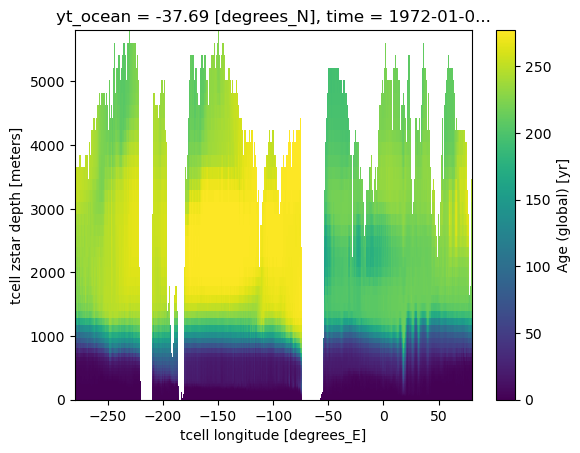

In [11]:
d_tracer.age_global.isel(time = 0,yt_ocean = 3).plot()

In [58]:
# create the regridding weights between our grids
regridder_tracer = xe.Regridder(
    d_tracer.rename(xt_ocean="lon", yt_ocean="lat"),
    dg_out,
    "bilinear",
    periodic=True,
    locstream_out=True,
    reuse_weights=False,
    filename="/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/age_bilinear_tracer_weights.nc",
)
# now we can apply it to input DataArrays:
ds_out = xr.merge([regridder_tracer(d_tracer)])

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/xesmf/frontend.py:718: UserWarning: Using dimensions ('yt_ocean', 'xt_ocean') from data variable age_global as the horizontal dimensions for the regridding.
  warnings.warn(


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 18.36 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-09-01 16:00:27,774 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 19.07 GiB -- Worker memory limit: 30.62 GiB


(6000.0, 0.0)

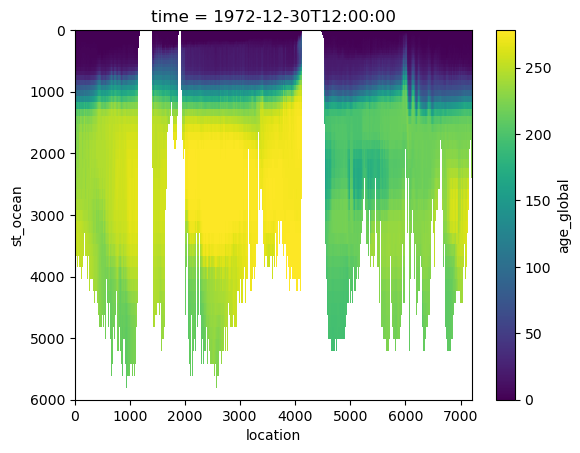

In [59]:
ds_out.age_global.isel(time=-1).plot()
plt.ylim(6000,0)

## Evaluating trend

Age values above were extracted from the last year of our RYF simulation, in a daily resolution. That means that the data will likely have a 1 year trend embedded in it. It might be worth checking this trend for sanitiy, and perhaps even detrending it.


In [60]:
ds_out_count = xr.DataArray(data=np.arange(0,ds_out.time.count()), dims='time',name='counting')
ds_out_count['time']= ds_out.time

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 18.36 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


(6000.0, 0.0)

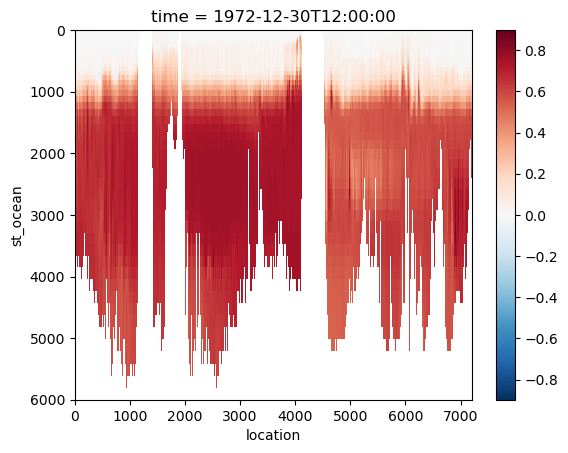

In [61]:
age_polyfit = ds_out.age_global.polyfit('time', deg=1)
age_trend = ((ds_out.age_global.polyfit('time', deg=1).polyfit_coefficients.sel(degree=0)) + \
((ds_out.age_global.polyfit('time', deg=1).polyfit_coefficients.sel(degree=1))*ds_out_count))/365
age_trend.isel(time=-1).plot()
plt.ylim(6000,0)

In [62]:
age_trend.isel(time=-1).max().values

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 18.36 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


array(0.89752941)

maximum increase in age through the linear trend we find is about 0.9 years. linear increas happens in the Mixed layer. we can just detrend the data based on that

In [63]:
#detrending data!
ds_out['age_global'] = ds_out.age_global - age_trend

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 18.36 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


(6000.0, 0.0)

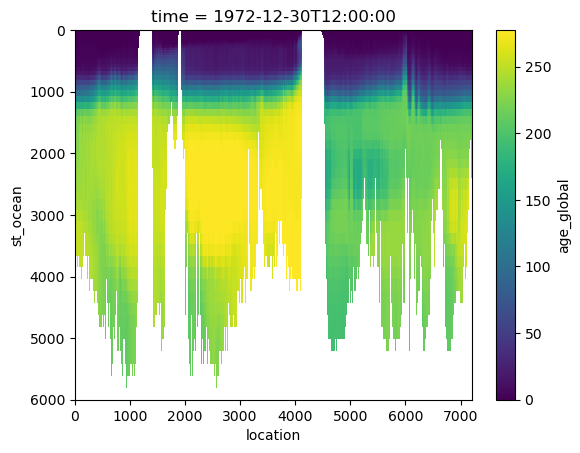

In [64]:
#detrended age
ds_out.age_global.isel(time=-1).plot()
plt.ylim(6000,0)

In [65]:
# Then fill in NaNs in the rest:
#### THIS IS THE PROBLEM #####
ds_out = (
    ds_out
    .ffill("st_ocean") #fill through all depth
    .interpolate_na("location") #fill nans horizontally
    .ffill("location") #these lines don't do anything
    .bfill("location") #these lines don't do anything
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 18.36 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-09-01 16:07:13,624 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 20.53 GiB -- Worker memory limit: 30.62 GiB


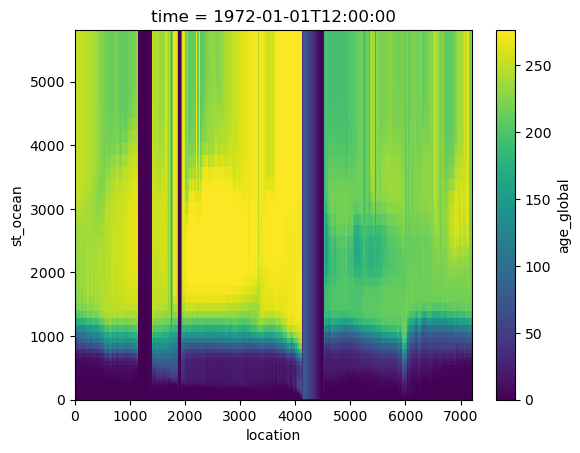

In [66]:
ds_out.age_global.isel(time = 0).plot()

# change order of filling

do location fill first, then st_ocean

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/xesmf/frontend.py:718: UserWarning: Using dimensions ('yt_ocean', 'xt_ocean') from data variable age_global as the horizontal dimensions for the regridding.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 18.36 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


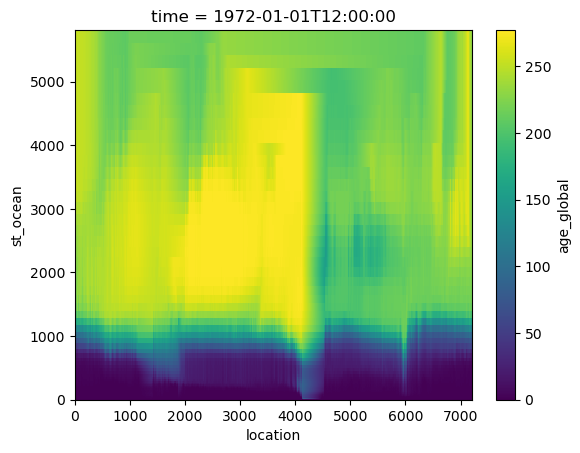

In [67]:
ds_out2 = xr.merge([regridder_tracer(d_tracer)])
# Then fill in NaNs in the rest:
#### THIS IS THE PROBLEM #####
## Try: first fill down i
ds_out2 = (
#    np.maximum(ds_out.where(ds_out.st_ocean>500).ffill("st_ocean").fillna(-999),
#           ds_out.fillna(-1000)).where(ds_out>-998)
    ds_out2.interpolate_na("location").ffill("st_ocean")
#    .ffill("location")
#    .bfill("location")
#    .ffill("st_ocean")
#    .interpolate_na("location")
)
ds_out2.age_global.isel(time = 0).plot()
plt.show()


# try to deal with open ocean cells first then land

Do vertical filling if greater than a specific depth (`depth_choice`), then horizontal fill

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/xesmf/frontend.py:718: UserWarning: Using dimensions ('yt_ocean', 'xt_ocean') from data variable age_global as the horizontal dimensions for the regridding.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 18.36 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


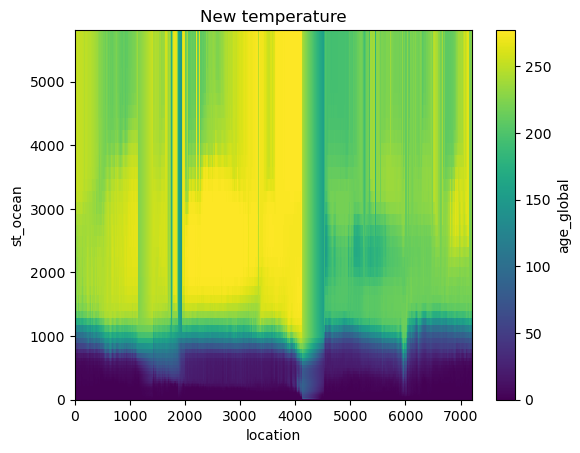

In [68]:
ds_out3 = xr.merge([regridder_tracer(d_tracer)])
# first fill nans in thickness with zeros, so the flood filling is not applied to them:
# ds_out3['dzt'] = ds_out3.dzt.fillna(0)
# ds_out3['dzu'] = ds_out3.dzu.fillna(0)

# Then fill in NaNs in the rest:
#### THIS IS THE PROBLEM #####
depth_choice = 1000
intermediate =     np.maximum(ds_out3.fillna(-1e34),ds_out3.where(ds_out.st_ocean>depth_choice).ffill("st_ocean").fillna(-2e34))
ds_out3 = intermediate.where(intermediate>-1e30) ## THIS IS original with FILLED in ST OCEAN direction if depth > depth_choice
ds_out3 = ds_out3.interpolate_na("location")

ds_out3.age_global.isel(time = 0).plot()
plt.title('New temperature')
plt.show()



# I am not sure if this is legit from a velocity point of view. And there is definitely sensitivity to choice of `depth_choice`. But I will try to make the file anyway and see how it runs.

Note want to keep original eta_t

In [69]:
ds_out["age_global"] = ds_out3["age_global"]
ds_out

<xarray.Dataset> Size: 2GB
Dimensions:     (st_ocean: 75, time: 365, location: 7201)
Coordinates:
  * st_ocean    (st_ocean) float64 600B 0.5413 1.681 ... 5.511e+03 5.709e+03
  * time        (time) datetime64[ns] 3kB 1972-01-01T12:00:00 ... 1972-12-30T...
Dimensions without coordinates: location
Data variables:
    age_global  (time, st_ocean, location) float64 2GB dask.array<chunksize=(365, 75, 7201), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

In [70]:
# including also dzt
original_forcing = xr.open_dataset('/g/data/ik11/inputs/mom6/panan/01deg/20230404/forcing/forcing_access_yr2_01.nc')
original_forcing_dz = original_forcing.rename({'dz_pot_temp_segment_001':'dz_age_global_segment_001'}).rename({'nz_segment_001_pot_temp':'nz_segment_001_age_global'})
original_forcing_dz.dz_age_global_segment_001

<xarray.DataArray 'dz_age_global_segment_001' (time: 365,
                                               nz_segment_001_age_global: 75,
                                               ny_segment_001: 1,
                                               nx_segment_001: 7201)> Size: 2GB
[197127375 values with dtype=float64]
Coordinates:
  * time                       (time) object 3kB 1900-01-01 12:00:00 ... 1900...
  * nz_segment_001_age_global  (nz_segment_001_age_global) int32 300B 0 1 ... 74
  * nx_segment_001             (nx_segment_001) int32 29kB 0 1 2 ... 7199 7200
  * ny_segment_001             (ny_segment_001) int32 4B 0

In [72]:
# fix up all the coordinate metadata
ds_out = ds_out.rename(location="nx_segment_001")
for var in surface_vars:
    ds_out[var] = ds_out[var].rename(st_ocean=f"nz_segment_001_{var}")
    ds_out = ds_out.rename({var: f"{var}_segment_001"})
    ds_out[f"nz_segment_001_{var}"] = np.arange(ds_out[f"nz_segment_001_{var}"].size)

# for var in line_tracer_vars:
#     ds_out = ds_out.rename({var: f"{var}_segment_001"})

# segment coordinates (x, y, z)
ds_out["nx_segment_001"] = np.arange(ds_out["nx_segment_001"].size)
ds_out["ny_segment_001"] = [0]

# lat/lon/depth/dz
ds_out["lon_segment_001"] = (["ny_segment_001", "nx_segment_001"], dg.x.data)
ds_out["lat_segment_001"] = (["ny_segment_001", "nx_segment_001"], dg.y.data)

# reset st_ocean so it's not an index coordinate
ds_out = ds_out.reset_index("st_ocean").reset_coords("st_ocean")
depth = ds_out["st_ocean"]
depth.name = "depth"
depth["st_ocean"] = np.arange(depth["st_ocean"].size)
del ds_out["st_ocean"]
ds_out['dz_age_global_segment_001'] = original_forcing_dz.dz_age_global_segment_001.astype('double')

In [74]:
# nx, ny and nz have to be int, otherwise the model will crash
encoding_dict = {
    "time": {
        "dtype": "double",},
        #"units": "days since 1900-01-01 12:00:00",
        #"calendar": "noleap",},
    "nx_segment_001": {"dtype": "int32",},
    "ny_segment_001": {"dtype": "int32",},
    "nz_segment_001_age_global": {"dtype": "int32",},
    "agessc_segment_001": {"dtype": "double",},
}

In [75]:
# add the y dimension to dz:
# ds_out["dzt_segment_001"] = ds_out["dzt_segment_001"].expand_dims("ny_segment_001", axis=2)
# ds_out["dzu_segment_001"] = ds_out["dzu_segment_001"].expand_dims("ny_segment_001", axis=2)

# for var in line_tracer_vars:
#     ds_out[f"{var}_segment_001"] = ds_out[f"{var}_segment_001"].expand_dims(
#         "ny_segment_001", axis=1
#     )
    
#     encoding_dict[f"{var}_segment_001"] = {"_FillValue": netCDF4.default_fillvals["f8"],}

# don't do for dzt or dzu:
# for var in (surface_vars[:2] + surface_vars[3:5]):
#     if var == 'age_global':
#         ds_out[f"{var}_segment_001"] = ds_out[f"{var}_segment_001"] - 273.15 # Celsius
#     # add the y dimension
#     ds_out[f"{var}_segment_001"] = ds_out[f"{var}_segment_001"].expand_dims(
#         "ny_segment_001", axis=2
#     )
    

    # ds_out[f"dz_{var}_segment_001"] = (
    #     ["time", f"nz_segment_001_{var}", "ny_segment_001", "nx_segment_001"],
    #     ds_out["nz_segment_001_age_global"].data)
    
    # encoding_dict[f"{var}_segment_001"] = {
    #     "_FillValue": netCDF4.default_fillvals["f8"],
    #     "zlib": True, 
    # }
    # encoding_dict[f"nz_segment_001_{var}"] = {
    #     "dtype": "int32"
    # }


In [76]:
# # add the y dimension to dz:
# # ds_out["dzt_segment_001"] = ds_out["dzt_segment_001"].expand_dims("ny_segment_001", axis=2)
# # ds_out["dzu_segment_001"] = ds_out["dzu_segment_001"].expand_dims("ny_segment_001", axis=2)

# for var in line_tracer_vars:
#     ds_out[f"{var}_segment_001"] = ds_out[f"{var}_segment_001"].expand_dims(
#         "ny_segment_001", axis=1
#     )
    
#     encoding_dict[f"{var}_segment_001"] = {"_FillValue": netCDF4.default_fillvals["f8"],}

# # don't do for dzt or dzu:
# for var in (surface_vars[:2] + surface_vars[3:5]):
#     if var == 'age_global':
#         ds_out[f"{var}_segment_001"] = ds_out[f"{var}_segment_001"] - 273.15 # Celsius
#     # add the y dimension
#     ds_out[f"{var}_segment_001"] = ds_out[f"{var}_segment_001"].expand_dims(
#         "ny_segment_001", axis=2
#     )
    
#     if var in surface_tracer_vars:
#     ds_out[f"dz_{var}_segment_001"] = (
#         ["time", f"nz_segment_001_{var}", "ny_segment_001", "nx_segment_001"],
#         ds_out["nzt_segment_001"].data)
#     else:
#         ds_out[f"dz_{var}_segment_001"] = (
#             ["time", f"nz_segment_001_{var}", "ny_segment_001", "nx_segment_001"],
#             ds_out["dzu_segment_001"].data)
    
#     encoding_dict[f"{var}_segment_001"] = {
#         "_FillValue": netCDF4.default_fillvals["f8"],
#         "zlib": True, 
#     }
#     encoding_dict[f"dz_{var}_segment_001"] = {
#         "_FillValue": netCDF4.default_fillvals["f8"],
#         "zlib": True, 
#     }
#     encoding_dict[f"nz_segment_001_{var}"] = {
#         "dtype": "int32"
#     }

# # we don't need dz_segment_001:
# ds_out = ds_out.drop_vars('dzt_segment_001')
# ds_out = ds_out.drop('nz_segment_001_dzt')
# ds_out = ds_out.drop_vars('dzu_segment_001')
# ds_out = ds_out.drop('nz_segment_001_dzu')

In [77]:
ds_old = xr.open_dataset("/g/data/x77/ahg157/inputs/mom6/panan/forcing_obc_shifted.nc", decode_times=False)

# time on ds_om4 was wacky:
ds_out["time"] = ds_old.time

# replace lat/lon:
ds_out = ds_out.drop_vars('lon_segment_001')
ds_out = ds_out.drop_vars('lat_segment_001')

ds_out["ilist_segment_001"] = (ds_old.ilist_segment_001)
ds_out["jlist_segment_001"] = (ds_old.ilist_segment_001)

In [78]:
ds_out.attrs["description"] = "Brushcut for age at the boundary from ACCESS-OM2-01 last RYF year daily data onto panan01 grid, filled in a specific way to reduce problems at continent boundaries"
ds_out

<xarray.Dataset> Size: 3GB
Dimensions:                    (time: 365, nz_segment_001_age_global: 75,
                                nx_segment_001: 7201, ny_segment_001: 1)
Coordinates:
  * time                       (time) float64 3kB 0.0 1.0 2.0 ... 363.0 364.0
  * nz_segment_001_age_global  (nz_segment_001_age_global) int64 600B 0 1 ... 74
  * nx_segment_001             (nx_segment_001) int64 58kB 0 1 2 ... 7199 7200
  * ny_segment_001             (ny_segment_001) int64 8B 0
Data variables:
    age_global_segment_001     (time, nz_segment_001_age_global, nx_segment_001) float64 2GB dask.array<chunksize=(365, 75, 7201), meta=np.ndarray>
    dz_age_global_segment_001  (time, nz_segment_001_age_global, ny_segment_001, nx_segment_001) float64 2GB ...
    ilist_segment_001          (ny_segment_001, nx_segment_001) float64 58kB ...
    jlist_segment_001          (ny_segment_001, nx_segment_001) float64 58kB ...
Attributes:
    regrid_method:  bilinear
    description:    Brushcut for age at the boundary from ACCESS-OM2-01 last ...

In [79]:
%%time 

with ProgressBar():
    ## Add modulo attribute for MOM6 to treat as repeat forcing:
    ds_out["time"] = ds_out["time"].assign_attrs({"modulo":" "})
    ds_out.to_netcdf("/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/forcing_access_panan01_boundaryage.nc", encoding=encoding_dict, unlimited_dims="time")


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 18.36 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-09-01 16:17:22,812 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 20.54 GiB -- Worker memory limit: 30.62 GiB


CPU times: user 23.1 s, sys: 29.6 s, total: 52.7 s
Wall time: 1min 29s


# double check fill values. 


In [80]:
ds_out = xr.open_dataset("/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/forcing_access_panan01_boundaryage.nc", decode_times=False)

# # make doubles:
ds_out['age_global_segment_001'] = ds_out['age_global_segment_001'].astype('double') #
# # ds_out['salt_segment_001'] = ds_out['salt_segment_001'].astype('double')
# # ds_out['eta_t_segment_001'] = ds_out['eta_t_segment_001'].astype('double')
# # ds_out['u_segment_001'] = ds_out['u_segment_001'].astype('double')
# # ds_out['v_segment_001'] = ds_out['v_segment_001'].astype('double')
# # ds_out['dz_u_segment_001'] = ds_out['dz_u_segment_001'].astype('double')
# # ds_out['dz_v_segment_001'] = ds_out['dz_v_segment_001'].astype('double')
# # ds_out['dz_pot_temp_segment_001'] = ds_out['dz_pot_temp_segment_001'].astype('double')
encoding_dict = {"age_global_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},}

ds_out.to_netcdf("/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/forcing_access_panan01_boundaryage_encoded.nc", encoding=encoding_dict, unlimited_dims="time")


time dimension in this age file seems to act up, so let's try create a unique file, by just adding the values I found for age here to the rpevious focing one and then using that for all

In [132]:
ds_out


<xarray.Dataset> Size: 3GB
Dimensions:                    (time: 365, nz_segment_001_age_global: 75,
                                nx_segment_001: 7201, ny_segment_001: 1)
Coordinates:
  * time                       (time) float64 3kB 0.0 1.0 2.0 ... 363.0 364.0
  * nz_segment_001_age_global  (nz_segment_001_age_global) int32 300B 0 1 ... 74
  * nx_segment_001             (nx_segment_001) int32 29kB 0 1 2 ... 7199 7200
  * ny_segment_001             (ny_segment_001) int32 4B 0
Data variables:
    age_global_segment_001     (time, nz_segment_001_age_global, nx_segment_001) float64 2GB ...
    dz_age_global_segment_001  (time, nz_segment_001_age_global, ny_segment_001, nx_segment_001) float64 2GB ...
    ilist_segment_001          (ny_segment_001, nx_segment_001) float64 58kB ...
    jlist_segment_001          (ny_segment_001, nx_segment_001) float64 58kB ...
Attributes:
    regrid_method:  bilinear
    description:    Brushcut for age at the boundary from ACCESS-OM2-01 last ...

In [134]:
ds_in = xr.open_dataset('/g/data/ik11/inputs/mom6/panan/01deg/20230404/forcing/forcing_access_yr2_01.nc')
ds_withage = ds_in.copy()
ds_withage['agessc_segment_001'] = ds_out['age_global_segment_001'].astype('double')
ds_withage['agessc_segment_001'].values = ds_out['age_global_segment_001'].astype('double').values
ds_withage['dz_agessc_segment_001'] = ds_out['dz_age_global_segment_001'].astype('double')
ds_withage['dz_agessc_segment_001'].values = ds_in['dz_pot_temp_segment_001'].astype('double').values
ds_withage = ds_withage.rename({'nz_segment_001_age_global':'nz_segment_001_agessc'})
ds_withage["time"] = ds_old.time

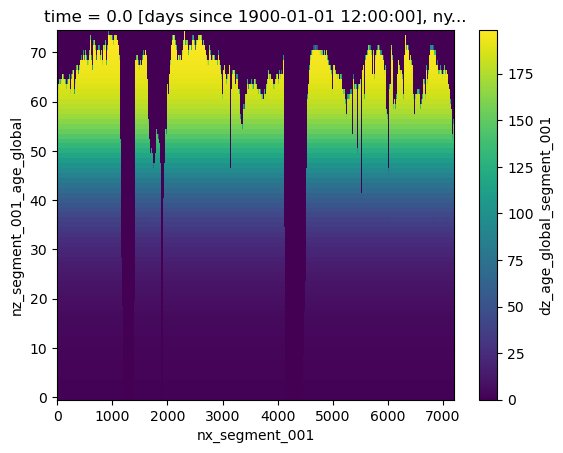

In [125]:
ds_withage['dz_age_global_segment_001'].isel(time=0).plot()

In [139]:
encoding_dict = {"agessc_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},}

In [140]:

ds_withage.to_netcdf("/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/bforcing_joined.nc", encoding=encoding_dict, unlimited_dims="time")

